In [1]:
!pip uninstall -y torchao
!pip install -U torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 12.0 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    """
    Custom Dataset cho CUB-200-2011 lấy cả Ảnh, Label và Caption.
    Đã tối ưu cho trường hợp 1 ảnh = 1 file caption duy nhất.
    """
    def __init__(self, root_dir, text_dir=None, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')

        if text_dir is None:
            base_dataset_dir = os.path.dirname(root_dir) # /content/dataset_cub/
            self.text_dir = os.path.join(base_dataset_dir, 'captions')
        else:
            self.text_dir = text_dir

        images_txt = os.path.join(root_dir, 'images.txt')
        split_txt = os.path.join(root_dir, 'train_test_split.txt')
        labels_txt = os.path.join(root_dir, 'image_class_labels.txt')
        classes_txt = os.path.join(root_dir, 'classes.txt')

        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        split_df = pd.read_csv(split_txt, sep=' ', names=['img_id', 'is_train'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'label'])
        classes_df = pd.read_csv(classes_txt, sep=' ', names=['class_id', 'class_name'])

        df = images_df.merge(split_df, on='img_id').merge(labels_df, on='img_id')

        target_split = 1 if self.is_train else 0
        df = df[df['is_train'] == target_split]

        self.image_paths = df['filepath'].tolist()
        self.labels = (df['label'] - 1).tolist()
        self.class_map = {}
        for _, row in classes_df.iterrows():
            class_name = row.class_name
            class_name = class_name.split('.', 1)[1]
            class_name = class_name.replace('_', ' ').lower()

            self.class_map[row.class_id - 1] = class_name

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]

        # image
        img_path = os.path.join(self.image_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # label
        label = self.labels[idx]

        # class name
        class_name = self.class_map[label]

        # caption
        text_rel_path = rel_path.replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        caption = f"a picture of {class_name}"
        if os.path.exists(text_path):
            with open(text_path, 'r', encoding='utf-8') as f:
                raw_caption = f.read().strip()

            caption = f"a picture of {class_name}. {raw_caption}"

        return image, label, caption.lower()

In [3]:
import torch
# import clip
# from PIL import Image
from torchvision import transforms
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize, RandomResizedCrop, RandomHorizontalFlip
from torch.utils.data import DataLoader

clip_normalize = transforms.Normalize(
    mean=(0.48145466, 0.4578275, 0.40821073),
    std=(0.26862954, 0.26130258, 0.27577711)
)

train_transforms = Compose([
    RandomResizedCrop(224, scale=(0.7, 1.0)), # Crop nhẹ
    RandomHorizontalFlip(),                   # Lật ngang
    ToTensor(),
    clip_normalize
])

test_transforms = Compose([
    Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    CenterCrop(224),
    ToTensor(),
    clip_normalize
])

cub_root_dir = '/kaggle/input/datasets/nmpogg/cub-caption/CUB_200_2011'

train_dataset = CUBDataset(root_dir=cub_root_dir, is_train=True, transform=train_transforms)
test_dataset = CUBDataset(root_dir=cub_root_dir, is_train=False, transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test:  {len(test_dataset)}")

Số lượng ảnh tập Train: 5994
Số lượng ảnh tập Test:  5794


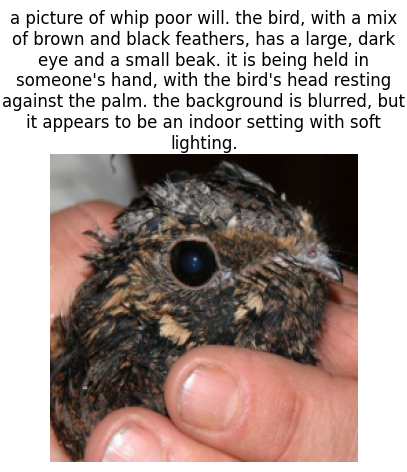

In [4]:
import matplotlib.pyplot as plt
import numpy as np

images, labels, captions = next(iter(train_loader))

img_tensor = images[0]
label_id = labels[0].item()
caption_text = captions[0]

def show_sample(img, title):
    mean = np.array([0.48145466, 0.4578275, 0.40821073])
    std  = np.array([0.26862954, 0.26130258, 0.27577711])
    img = img.cpu().numpy()

    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title, wrap=True)
    plt.axis('off')
    plt.show()

show_sample(img_tensor, title=f"{caption_text}")

In [5]:
from torch import nn
from transformers import CLIPModel, CLIPProcessor
from peft import LoraConfig, get_peft_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "openai/clip-vit-base-patch16"
base_model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.1,
    bias="none"
)

lora_model = get_peft_model(base_model, lora_config).to(device)

print("Thống kê tham số:")
lora_model.print_trainable_parameters()

# 2 hàm CrossEntropy để đối chiếu 2 chiều (Ảnh -> Chữ, Chữ -> Ảnh)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(lora_model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Thống kê tham số:
trainable params: 1,966,080 || all params: 151,586,817 || trainable%: 1.2970


In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from safetensors.torch import save_file

num_epochs = 15

patience = 3
best_test_loss = float('inf')
epochs_no_improve = 0

print("BẮT ĐẦU FINE-TUNE CLIP + LoRA...")

for epoch in range(num_epochs):
    lora_model.train()
    running_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for images, _, captions in train_pbar:
        pixel_values = images.to(device)

        text_inputs = processor(
            text=list(captions),
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        ).to(device)

        optimizer.zero_grad()
        
        outputs = lora_model(pixel_values=pixel_values, **text_inputs, return_loss=True)
        
        # Loss InfoNCE tiêu chuẩn của CLIP
        loss = outputs.loss 
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # --- Bước Đánh giá (Tính Test Loss) ---
    lora_model.eval()
    test_loss_accum = 0.0
    with torch.no_grad():
        for images, _, captions in test_loader:
            pixel_values = images.to(device)
            text_inputs = processor(
                text=list(captions),
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77
            ).to(device)

            outputs = lora_model(pixel_values=pixel_values, **text_inputs, return_loss=True)
            test_loss_accum += outputs.loss.item()
            
    test_loss = test_loss_accum / len(test_loader)


    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # Lưu mô hình tốt nhất dựa trên test_loss
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        epochs_no_improve = 0
        print(f" => Test loss cải thiện. Lưu mô hình tốt nhất...")
        # Lưu LoRA weights
        lora_model.save_pretrained("./best_clip_lora")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping tại epoch {epoch+1}")
            break

print("Hoàn thành Fine-tune CLIP + LoRA!")

BẮT ĐẦU FINE-TUNE CLIP + LoRA...


Epoch [1/15] | Train Loss: 0.1589 | Test Loss: 1.4252
 => Test loss cải thiện. Lưu mô hình tốt nhất...


Epoch [2/15] | Train Loss: 0.0783 | Test Loss: 1.2978
 => Test loss cải thiện. Lưu mô hình tốt nhất...


Epoch [3/15] | Train Loss: 0.0525 | Test Loss: 1.2544
 => Test loss cải thiện. Lưu mô hình tốt nhất...


Epoch [4/15] | Train Loss: 0.0441 | Test Loss: 1.2164
 => Test loss cải thiện. Lưu mô hình tốt nhất...


...

Epoch [11/15] | Train Loss: 0.0302 | Test Loss: 1.0897
 => Test loss cải thiện. Lưu mô hình tốt nhất...


Epoch [12/15] | Train Loss: 0.0252 | Test Loss: 1.0799
 => Test loss cải thiện. Lưu mô hình tốt nhất...


Epoch [13/15] | Train Loss: 0.0253 | Test Loss: 1.0875


Epoch [14/15] | Train Loss: 0.0207 | Test Loss: 1.0680
 => Test loss cải thiện. Lưu mô hình tốt nhất...


Epoch [15/15] | Train Loss: 0.0216 | Test Loss: 1.0830
Hoàn thành Fine-tune CLIP + LoRA!


In [10]:
import numpy as np
from sentence_transformers import SentenceTransformer
from peft import PeftModel

# 1. Load lại mô hình tốt nhất đã huấn luyện
print("Đang load best model...")
model_name = "openai/clip-vit-base-patch16"
model = CLIPModel.from_pretrained(model_name)
best_lora_model = PeftModel.from_pretrained(model, "./best_clip_lora")
best_lora_model.to(device)
best_lora_model.eval()

# 2. Khởi tạo mô hình đánh giá Semantic (BERTScore/Sentence-BERT)
semantic_model = SentenceTransformer('BAAI/bge-large-en-v1.5').to(device)

def evaluate_custom_metrics(model, dataloader, processor, k_list=[1, 3, 5, 7, 10, 20], tau_semantic=0.8):
    all_image_embeds = []
    all_text_embeds = []
    all_captions = []

    # 1. Trích xuất toàn bộ Embedding của Test set
    with torch.no_grad():
        for images, _, captions in tqdm(dataloader, desc="Extracting CLIP Embeddings"):
            pixel_values = images.to(device)
            text_inputs = processor(
                text=list(captions),
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77
            ).to(device)

            outputs = model(pixel_values=pixel_values, **text_inputs)
            
            # Chuẩn hóa Embedding
            img_embeds = outputs.image_embeds / outputs.image_embeds.norm(p=2, dim=-1, keepdim=True)
            txt_embeds = outputs.text_embeds / outputs.text_embeds.norm(p=2, dim=-1, keepdim=True)
            
            all_image_embeds.append(img_embeds.cpu())
            all_text_embeds.append(txt_embeds.cpu())
            all_captions.extend(captions)
            
    # Gộp thành các tensor lớn
    image_embeds = torch.cat(all_image_embeds, dim=0) # (N, D)
    text_embeds = torch.cat(all_text_embeds, dim=0)   # (N, D)
    N = len(all_captions)

    # 2. Tính Test Loss (Image-Text Alignment Loss trên toàn gallery)
    logit_scale = model.logit_scale.exp().item() if hasattr(model, 'logit_scale') else 100.0
    logits_per_text = logit_scale * text_embeds @ image_embeds.T
    labels = torch.arange(N)
    test_loss = F.cross_entropy(logits_per_text, labels).item()

    # 3. Tính độ tương đồng ngữ nghĩa bằng Sentence Transformer
    print("Tính toán Text Semantic Embeddings...")
    cap_embeds = semantic_model.encode(all_captions, convert_to_tensor=True, device=device)
    cap_embeds = cap_embeds / cap_embeds.norm(p=2, dim=-1, keepdim=True)
    # Ma trận (N, N) chứa CosineSim của mọi cặp caption
    semantic_sim_matrix = (cap_embeds @ cap_embeds.T).cpu() 

    # 4. Tính toán các độ đo: MR, CRS@k, R@k_semantic
    mean_rank = 0.0
    crs_at_k = {k: 0.0 for k in k_list}
    recall_at_k_semantic = {k: 0.0 for k in k_list}
    
    # Text-to-Image Retrieval:
    sim_matrix = text_embeds @ image_embeds.T # (N, N)
    
    for i in range(N):
        # Sắp xếp các ảnh theo độ tương đồng với text query thứ i giảm dần
        scores = sim_matrix[i]
        ranked_indices = torch.argsort(scores, descending=True)
        
        # --- Mean Rank (MR) ---
        # Hạng của cặp positive (ảnh thứ i cho text thứ i)
        rank = (ranked_indices == i).nonzero(as_tuple=True)[0].item() + 1
        mean_rank += rank
        
        # Cờ để xác định positive set (semantic)
        semantic_positives = (semantic_sim_matrix[i] > tau_semantic).nonzero(as_tuple=True)[0]
        num_positives = len(semantic_positives)
        if num_positives == 0: 
            num_positives = 1 # Đề phòng mẫu bị cô lập
            
        for k in k_list:
            top_k_idx = ranked_indices[:k]
            
            # --- CRS@k ---
            # Semantic sim giữa query i và caption của các ảnh trả về
            k_sims = semantic_sim_matrix[i, top_k_idx]
            crs_at_k[k] += k_sims.mean().item()
            
            # --- R@k semantic ---
            # Bao nhiêu ảnh trong top k thuộc positive set (semantic > tau)
            hits = torch.isin(top_k_idx, semantic_positives).sum().item()
            recall_at_k_semantic[k] += hits / num_positives

    # Lấy trung bình
    mean_rank /= N
    for k in k_list:
        crs_at_k[k] /= N
        recall_at_k_semantic[k] /= N

    # In kết quả
    print("\n" + "="*40)
    print("KẾT QUẢ ĐÁNH GIÁ (EVALUATION METRICS)")
    print("="*40)
    print(f"1. Image-Text Alignment Loss (Test Loss): {test_loss:.4f}")
    print(f"2. Mean Rank (MR): {mean_rank:.2f}")
    print("-" * 40)
    
    for k in k_list:
        print(f"K = {k:2d} | CRS@{k}: {crs_at_k[k]:.4f} | R@{k} (semantic): {recall_at_k_semantic[k]:.4f}")
        
    return {
        "test_loss": test_loss,
        "mean_rank": mean_rank,
        "crs_at_k": crs_at_k,
        "recall_at_k_semantic": recall_at_k_semantic
    }

# Gọi hàm đánh giá
metrics = evaluate_custom_metrics(
    model=best_lora_model, 
    dataloader=test_loader, 
    processor=processor, 
    k_list=[1, 3, 5, 7, 10, 20], 
    tau_semantic=0.8 # Bạn có thể đổi ngưỡng similarity mong muốn
)

Đang load best model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Extracting CLIP Embeddings: 100%|██████████| 182/182 [01:33<00:00,  1.94it/s]


Tính toán Text Semantic Embeddings...

KẾT QUẢ ĐÁNH GIÁ (EVALUATION METRICS)
1. Image-Text Alignment Loss (Test Loss): 1.9068
2. Mean Rank (MR): 4.86
----------------------------------------
K =  1 | CRS@1: 0.9462 | R@1 (semantic): 0.0144
K =  3 | CRS@3: 0.9072 | R@3 (semantic): 0.0378
K =  5 | CRS@5: 0.8900 | R@5 (semantic): 0.0585
K =  7 | CRS@7: 0.8792 | R@7 (semantic): 0.0775
K = 10 | CRS@10: 0.8676 | R@10 (semantic): 0.1035
K = 20 | CRS@20: 0.8437 | R@20 (semantic): 0.1742
